# English Sentiment Analysis Demo

This notebook demonstrates a complete end-to-end sentiment analysis system for English:

- Text preprocessing (custom NLP pipeline)
- TF-IDF feature extraction
- Logistic Regression classifier
- Sentiment prediction with probabilities

### Classes:
- Negative
- Neutral
- Positive

### Environment Setup

In [ ]:
from pathlib import Path # Path Handling
import pandas as pd # Data Handling

# Project Modules
from utils import load_csv # Data Loading and Preparation
from projects.sentiment_analysis.russian_classifier.code.preprocess_ru import preprocess_text # Text Preprocessing Function
from predict_model import predict_sentiment, predict_proba, predict_batch_detailed # Prediction Functions

### Load Model and Vectorizer

In [2]:
BASE_DIR = Path().resolve().parents[0] # Base Directory
DATA_DIR = BASE_DIR / "data" # Data Directory

data_path = DATA_DIR / "train_en.csv"  # Dataset Path

df = load_csv(data_path) # Load Dataset

# Display Dataset Info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (166, 2)


,text,sentiment
0,"I absolutely love this product, it works perfe...",positive
1,This is the worst experience I have ever had.,negative
2,The movie was really enjoyable and fun.,positive
3,I am very disappointed with the quality.,negative
4,"The service was okay, nothing special.",neutral


### Data Overview

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_4044\3558776122.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


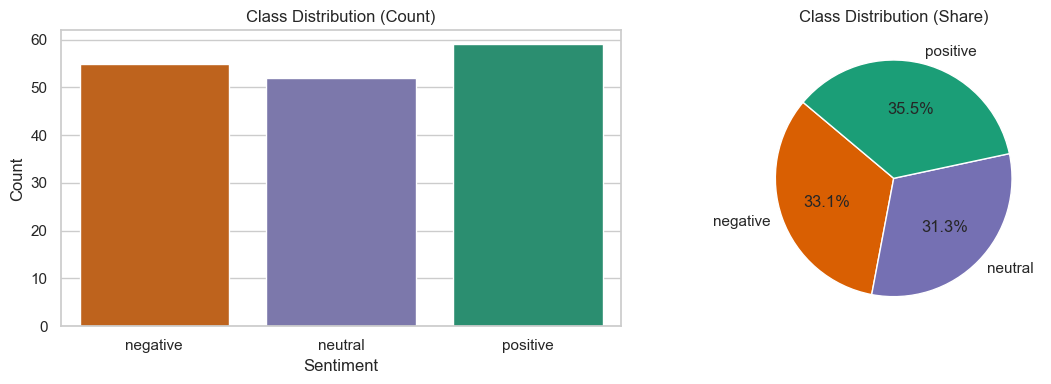

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

label_order = ["negative", "neutral", "positive"]
label_map_numeric = {0: "negative", 1: "neutral", 2: "positive"}

label_series = df["sentiment"].map(label_map_numeric).fillna(df["sentiment"].astype(str).str.lower())
class_counts = label_series.value_counts().reindex(label_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0]
    )
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=["#d95f02", "#7570b3", "#1b9e77"],
    startangle=140
    )
axes[1].set_title("Class Distribution (Share)")

plt.tight_layout()
plt.show()

In [4]:
# Display Class Distribution
print("Class Distribution:")
print(df["sentiment"].value_counts())

Class Distribution:
sentiment
positive    59
negative    55
neutral     52
Name: count, dtype: int64


### Preprocessing Demo

In [5]:
sample = "I can't believe how amazing this product is!!!" # Sample text for preprocessing
processed_text = preprocess_text(sample) # Preprocess sample text

print(f"Orinal Text: {sample}")
print(f"\nProcessed Text: {processed_text}")


Orinal Text: I can't believe how amazing this product is!!!

Processed Text: can not believe amazing product


### Model Training Explanation

The model was trained using `train_model.py` with:

- TF-IDF vectorization (unigrams + bigrams)
- Logistic Regression classifier
- gistic Regression classifier
- Calibrated probabilities for better confidence estimates
- Stratified train/test split
- Label mapping:
  - negative → 0
  - neutral → 1
  - positive → 2

The trained model and vectorizer are saved and reused for prediction.

### Single Text Prediction

In [6]:
text = "This movie was fantastic! I loved it." # Sample text for prediction

prediction = predict_sentiment(text) # Predict sentiment
probabilities = predict_proba(text) # Get prediction probabilities

print(f"Text: {text}") 
print(f"Prediction: {prediction}")
print("Probabilites:")
for l, s in probabilities.items():
    print(f"\t{l}: {s:.3f}")

Text: This movie was fantastic! I loved it.
Prediction: positive
Probabilites:
	negative: 0.208
	neutral: 0.123
	positive: 0.669


### Batch Text Prediction

In [7]:
# Sample texts for predictions
examples = [
    "I absolutely loved this! Best experience ever.",
    "This is the worst thing I've ever bought.",
    "It's okay, not great but not terrible either.",
    "I'm so happy with this purchase! Exceeded my expectations.",
    "Terrible quality, broke after one use. Do not recommend."
]

results = predict_batch_detailed(examples) # Get detailed predictions for batch of texts

for item in results:
    print(f"\nText: {item['text']}")
    print(f"Prediction: {item['prediction']}")
    print("Probabilities:")
    for l, s in item["probabilities"].items():
        print(f"\t{l}: {s:.3f}")


Text: I absolutely loved this! Best experience ever.
Prediction: neutral
Probabilities:
	negative: 0.404
	neutral: 0.141
	positive: 0.455

Text: This is the worst thing I've ever bought.
Prediction: neutral
Probabilities:
	negative: 0.432
	neutral: 0.256
	positive: 0.312

Text: It's okay, not great but not terrible either.
Prediction: negative
Probabilities:
	negative: 0.512
	neutral: 0.244
	positive: 0.244

Text: I'm so happy with this purchase! Exceeded my expectations.
Prediction: positive
Probabilities:
	negative: 0.250
	neutral: 0.151
	positive: 0.599

Text: Terrible quality, broke after one use. Do not recommend.
Prediction: negative
Probabilities:
	negative: 0.549
	neutral: 0.095
	positive: 0.356


### Clean Table Output

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_4044\1150015042.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


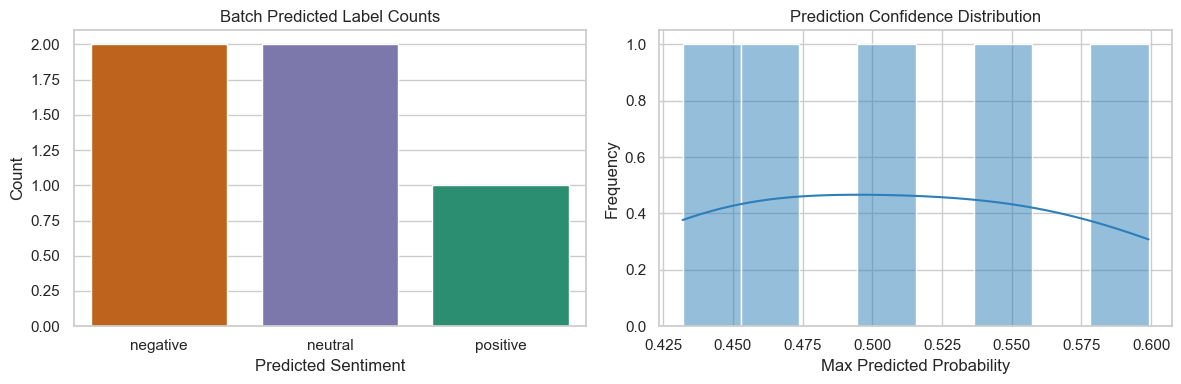

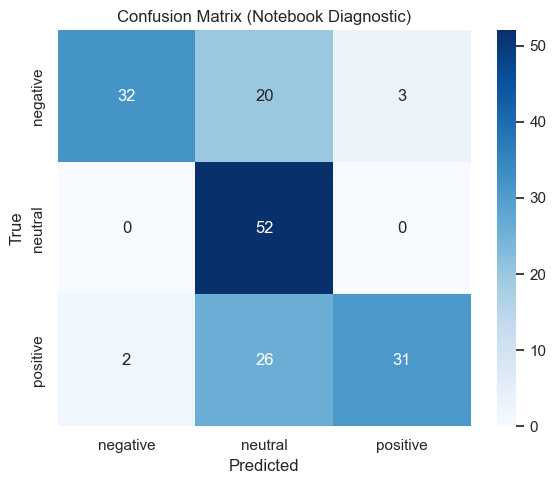

Classification Report (Notebook Diagnostic):
              precision    recall  f1-score   support

    negative       0.94      0.58      0.72        55
     neutral       0.53      1.00      0.69        52
    positive       0.91      0.53      0.67        59

    accuracy                           0.69       166
   macro avg       0.79      0.70      0.69       166
weighted avg       0.80      0.69      0.69       166



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

label_order = ["negative", "neutral", "positive"]

# 1) Batch prediction summary charts
results_df = pd.DataFrame(results)
proba_df = pd.DataFrame(results_df["probabilities"].tolist())

pred_counts = results_df["prediction"].value_counts().reindex(label_order, fill_value=0)
confidence = proba_df.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=pred_counts.index,
    y=pred_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0]
    )
axes[0].set_title("Batch Predicted Label Counts")
axes[0].set_xlabel("Predicted Sentiment")
axes[0].set_ylabel("Count")

sns.histplot(confidence, bins=8, kde=True, color="#2c7fb8", ax=axes[1])
axes[1].set_title("Prediction Confidence Distribution")
axes[1].set_xlabel("Max Predicted Probability")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 2) Quick confusion matrix on notebook dataset
eval_df = df[["text", "sentiment"]].dropna().copy()
true_labels = eval_df["sentiment"].map({0: "negative", 1: "neutral", 2: "positive"}).fillna(
    eval_df["sentiment"].astype(str).str.lower()
    )
valid_mask = true_labels.isin(label_order)
eval_df = eval_df[valid_mask]
true_labels = true_labels[valid_mask]

pred_labels = eval_df["text"].apply(predict_sentiment)
cm = confusion_matrix(true_labels, pred_labels, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order
    )
plt.title("Confusion Matrix (Notebook Diagnostic)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("Classification Report (Notebook Diagnostic):")
print(classification_report(true_labels, pred_labels, labels=label_order, zero_division=0))

In [9]:
pd.DataFrame(results)

,text,prediction,probabilities
0,I absolutely loved this! Best experience ever.,neutral,"{'negative': 0.40410704572307915, 'neutral': 0..."
1,This is the worst thing I've ever bought.,neutral,"{'negative': 0.43198625231866, 'neutral': 0.25..."
2,"It's okay, not great but not terrible either.",negative,"{'negative': 0.5116711387270838, 'neutral': 0...."
3,I'm so happy with this purchase! Exceeded my e...,positive,"{'negative': 0.2498938751337428, 'neutral': 0...."
4,"Terrible quality, broke after one use. Do not ...",negative,"{'negative': 0.5490580689008534, 'neutral': 0...."


### Interactive Demo

In [10]:
user_input = input("Enter a text to analyze sentiment: ") # Get user input
user_prediction = predict_sentiment(user_input) # Predict sentiment for user input
print(f"Predicted Sentiment: {user_prediction}")

Predicted Sentiment: neutral
